   Calories  Total Fat  Saturated Fat  Monounsaturated Fat  \
0     149.0          0            0.0                  0.0   
1     123.0          0            0.0                  0.0   
2     150.0          0            0.0                  0.0   
3     110.0          0            0.0                  0.0   
4     143.0          0            0.0                  0.0   

   Polyunsaturated Fat  Trans Fat  Cholesterol  Sodium  Total Carbohydrate  \
0                  0.0        0.0            0     9.0                 9.8   
1                  0.0        0.0            0     5.0                 6.6   
2                  0.0        0.0            0     4.0                11.4   
3                  0.0        0.0            0     6.0                 7.0   
4                  0.0        0.0            0     7.0                13.1   

   Dietary Fiber  Sugars  Sugar Alcohol  Protein  Vitamin A  Vitamin C  \
0            0.0     0.0              0      1.3          0          0   
1         

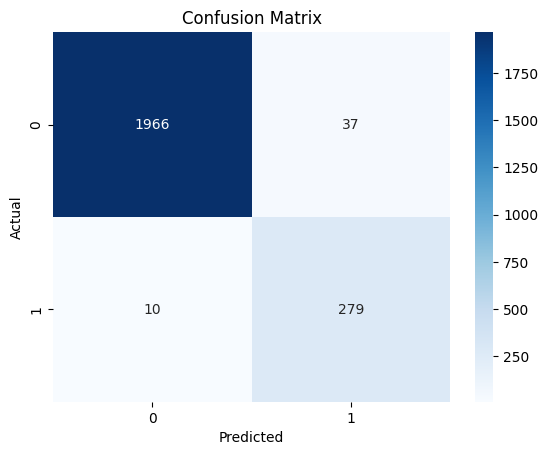

In [14]:
#Step 1 import libraries
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import seaborn as sns
import matplotlib.pyplot as plt
#Step 2
#Load dataset
data=pd.read_csv('food_items_binary.csv.xls')
print(data.head())
print(data.columns)
#selecting features and target
features=['Calories','Total Fat','Saturated Fat','Sugars','Dietary Fiber','Protein']
target='class'
x=data[features]
y=data[target]
#step 4
#splitting data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=42)
#step 5 feature scaling
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
#step 6 model training
svm = SVC()
#Setup hyperparameter grid for tuning
param_grid={
'C':[0.1,1,10,100], #regularization parameter
'kernel':['linear','rbf'], #kernel types
'gamma':['scale','auto'] #kernel coefficient
}
#initialize gridsearchCV
grid_search=GridSearchCV(svm,param_grid,cv=5,scoring='accuracy')
grid_search.fit(x_train,y_train)
#Extract best model
best_model=grid_search.best_estimator_
print("Name:Branzen")
print("Register No:212225100005")
print("Best Parameters:", grid_search.best_params_)
#step 7 Model Evaluation
y_pred=best_model.predict(x_test)
#calculate accuracy and print classification matrix
accuracy=accuracy_score(y_test,y_pred)
print("Name:Branzen")
print("Register No:212225100005")
print("Accuracy:",accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
#confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
